# 08 - Operational Results Analysis and Publication Figures

This notebook is the **post-optimization publication layer** for the operational and resilient experiments.

It does **not** invoke Pyomo or HiGHS and does not rerun any MILP.

It reads the saved results from Notebook 07 V4 and produces:

1. validation tables;
2. the classical-to-operational-to-resilient infrastructure comparison;
3. the resilience premium;
4. demand-intensity sensitivity;
5. response-time sensitivity;
6. battery-endurance sensitivity;
7. turnaround-time sensitivity;
8. a consolidated operational sensitivity figure;
9. maps of the baseline nonredundant and resilient solutions;
10. publication-ready CSV tables.

## Main baseline comparison

The results established in Notebook 07 are:

- classical geographic benchmark: 3 hubs;
- operational baseline without redundancy: 7 hubs and 19 drones;
- resilient baseline: 10 hubs and 21 drones.

The classical value is a benchmark from Notebook 05 under different assumptions and must be described as a **progressive modeling comparison**, not as a directly interchangeable estimate.

## 0. Imports and paths

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

PROJECT_ROOT = Path("hajj_drone_project")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "data" / "model"
NB05_DIR = MODEL_DIR / "optimization_solutions"
NB07_DIR = MODEL_DIR / "operational_resilient_solutions_v4"

FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "operational_paper"
TABLE_DIR = PROJECT_ROOT / "outputs" / "reports" / "operational_paper"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 120
})

def savefig(fig, name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print("Saved:", png)
    return png

## 1. Load Notebook 07 V4 checkpoints

In [15]:
files = {
    "resilience": NB07_DIR / "fixed_p_resilience_comparison_v4.csv",
    "baseline": NB07_DIR / "baseline_endogenous_comparison_v4.csv",
    "scenarios": NB07_DIR / "sensitivity_scenarios_v4.csv",
    "sensitivity": NB07_DIR / "endogenous_sensitivity_results_v4.csv",
    "hub_fleet": NB07_DIR / "selected_hubs_fleet_v4.csv",
    "flows": NB07_DIR / "package_flows_v4.csv"
}

missing = [str(p) for p in files.values() if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing Notebook 07 V4 outputs:\n" + "\n".join(missing)
    )

resilience = pd.read_csv(files["resilience"])
baseline = pd.read_csv(files["baseline"])
scenarios = pd.read_csv(files["scenarios"])
sensitivity = pd.read_csv(files["sensitivity"])
hub_fleet = pd.read_csv(files["hub_fleet"])
flows = pd.read_csv(files["flows"])

print("Fixed-p resilience runs:", len(resilience))
print("Baseline endogenous runs:", len(baseline))
print("Sensitivity runs:", len(sensitivity))
print("Hub/fleet records:", len(hub_fleet))
print("Package-flow records:", len(flows))

Fixed-p resilience runs: 16
Baseline endogenous runs: 2
Sensitivity runs: 10
Hub/fleet records: 91
Package-flow records: 300


## 2. Validate the saved results

In [16]:
print("=" * 68)
print("NOTEBOOK 07 V4 CHECKPOINT VALIDATION")
print("=" * 68)

assert len(resilience) == 16
assert len(baseline) == 2
assert len(sensitivity) == 10
assert len(hub_fleet) == 91
assert len(flows) == 300

b1 = baseline.loc[baseline["redundancy"] == 1].iloc[0]
b2 = baseline.loc[baseline["redundancy"] == 2].iloc[0]

print(
    "Nonredundant baseline:",
    int(b1["minimum_hubs"]), "hubs,",
    int(b1["minimum_drones"]), "drones"
)

print(
    "Resilient baseline:",
    int(b2["minimum_hubs"]), "hubs,",
    int(b2["minimum_drones"]), "drones"
)

assert int(b1["minimum_hubs"]) == 7
assert int(b1["minimum_drones"]) == 19
assert int(b2["minimum_hubs"]) == 10
assert int(b2["minimum_drones"]) == 21

print("\nCheckpoint validation passed.")

NOTEBOOK 07 V4 CHECKPOINT VALIDATION
Nonredundant baseline: 7 hubs, 19 drones
Resilient baseline: 10 hubs, 21 drones

Checkpoint validation passed.


# Publication Figure Set V2

The following figures are the **revised manuscript-quality outputs**. They are intentionally designed as a compact figure set rather than one plot per experiment.

Design principles:

- no redundant titles inside panels when captions can carry the explanation;
- consistent typography and 600-dpi PNG/PDF export;
- direct value labels on infrastructure plots;
- separate axes when hubs and drones are compared;
- battery sensitivity shown explicitly as a null effect;
- operational sensitivities consolidated into a small number of multi-panel figures;
- resilient spatial solution shown with readable hub labels and an explicit fleet-size legend;
- package-flow map uses active demand points only and a clear assignment-line legend.

The paper can later select a subset of these figures, but this notebook generates all of them first for visual review.

In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import matplotlib.patheffects as pe

FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "operational_paper_v2"
TABLE_DIR = PROJECT_ROOT / "outputs" / "reports" / "operational_paper_v2"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 130
})

def savefig(fig, name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print("Saved:", png)
    return png

# Baseline rows
b1 = baseline.loc[baseline["redundancy"] == 1].iloc[0]
b2 = baseline.loc[baseline["redundancy"] == 2].iloc[0]

def baseline_sensitivity_row():
    q = sensitivity[
        (sensitivity["packages_per_hour"] == 30)
        & np.isclose(sensitivity["safe_roundtrip_km"], 20.0)
        & np.isclose(sensitivity["response_target_min"], 5.0)
        & np.isclose(sensitivity["turnaround_min"], 30.0)
        & (sensitivity["redundancy"] == 2)
    ]
    if len(q) != 1:
        raise ValueError(f"Expected one resilient baseline row, found {len(q)}")
    return q.iloc[[0]].copy()

baseline_sens = baseline_sensitivity_row()

## Figure 1. From geographic coverage to operational resilience

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig01_progressive_infrastructure_v2.png


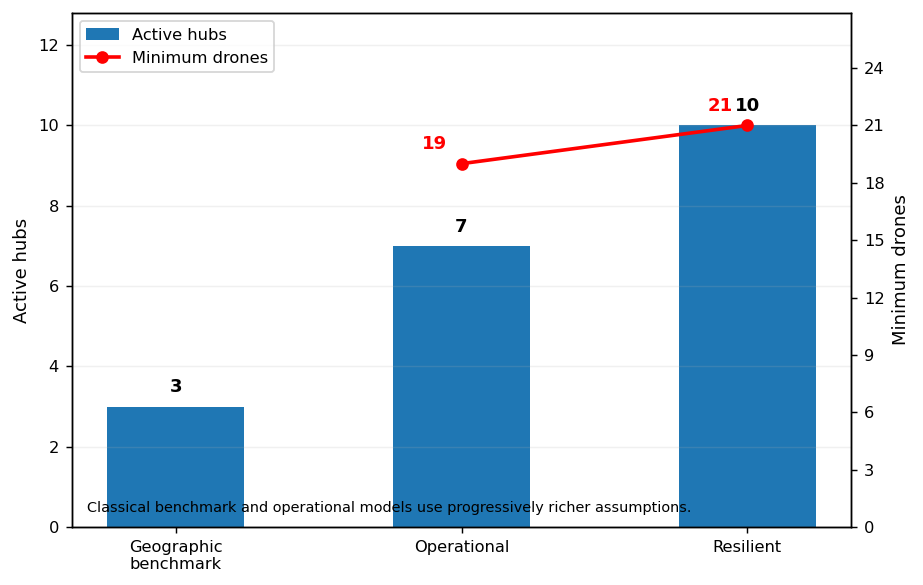

In [18]:
stages = ["Geographic\nbenchmark", "Operational", "Resilient"]
hubs_vals = [3, int(b1["minimum_hubs"]), int(b2["minimum_hubs"])]
drone_vals = [np.nan, int(b1["minimum_drones"]), int(b2["minimum_drones"])]

fig, ax1 = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(3)

bars = ax1.bar(x, hubs_vals, width=.48, label="Active hubs")
ax1.set_ylabel("Active hubs")
ax1.set_xticks(x)
ax1.set_xticklabels(stages)
ax1.set_ylim(0, max(hubs_vals) * 1.28)
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.grid(axis="y", alpha=.18)

for rect, val in zip(bars, hubs_vals):
    ax1.text(rect.get_x()+rect.get_width()/2, val+.25, str(val),
             ha="center", va="bottom", fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(x[1:], drone_vals[1:], marker="o", linewidth=2.0, label="Minimum drones",color = 'red')
ax2.set_ylabel("Minimum drones")
ax2.set_ylim(0, max(drone_vals[1:]) * 1.28)
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

for xi, val in zip(x[1:], drone_vals[1:]):
    ax2.annotate(str(val), (xi, val), xytext=(-15,8),
                 textcoords="offset points", ha="center", fontweight="bold",color = 'red')

lines = [bars, ax2.get_lines()[0]]
labels = ["Active hubs", "Minimum drones"]
ax1.legend(lines, labels, loc="upper left")

ax1.text(.02, .03,
         "Classical benchmark and operational models use progressively richer assumptions.",
         transform=ax1.transAxes, fontsize=8)

fig.tight_layout()
savefig(fig, "fig01_progressive_infrastructure_v2")
plt.show()

## Figure 2. Fixed-hub feasibility and resilience premium

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig02_fixed_p_resilience_v2.png


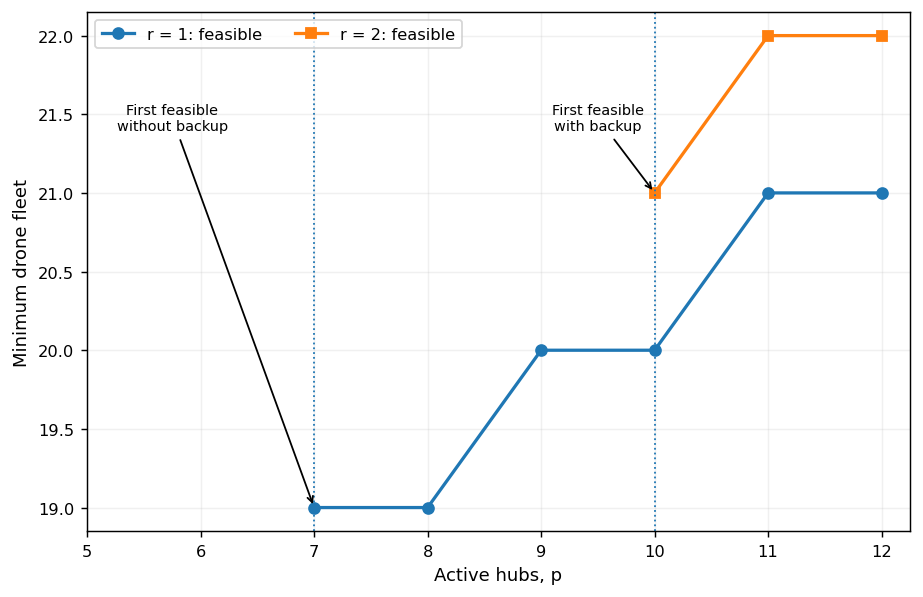

In [32]:
fig, ax = plt.subplots(figsize=(7.2, 4.7))

for r, marker in [(1, "o"), (2, "s")]:
    g = resilience[resilience["redundancy"] == r].sort_values("p")
    feasible = g[g["termination"] == "optimal"].copy()
    infeasible = g[g["termination"] != "optimal"].copy()

    ax.plot(feasible["p"], feasible["minimum_drones"],
            marker=marker, linewidth=1.8, label=f"r = {r}: feasible")

    if len(infeasible):
        y0 = 17.2 if r == 1 else 16.5
        ax.scatter(infeasible["p"], [y0]*len(infeasible),
                   marker="x", s=55, label=f"r = {r}: infeasible")

ax.axvline(7, linestyle=":", linewidth=1)
ax.axvline(10, linestyle=":", linewidth=1)
ax.annotate("First feasible\nwithout backup", (7,19), xytext=(5.75,21.4),
            arrowprops=dict(arrowstyle="->"), ha="center", fontsize=8)
ax.annotate("First feasible\nwith backup", (10,21), xytext=(9.5,21.4),
            arrowprops=dict(arrowstyle="->"), ha="center", fontsize=8)

ax.set_xlabel("Active hubs, p")
ax.set_ylabel("Minimum drone fleet")
ax.set_xticks(range(5,13))
ax.grid(alpha=.18)
ax.legend(ncol=2, loc="upper left")
fig.tight_layout()

savefig(fig, "fig02_fixed_p_resilience_v2")
plt.show()

## Figure 3. Operational sensitivity: demand and turnaround

These two parameters primarily affect throughput. Demand intensity changes the number of package missions, while turnaround changes the amount of time each mission occupies a drone.

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig03_throughput_sensitivity_v2.png


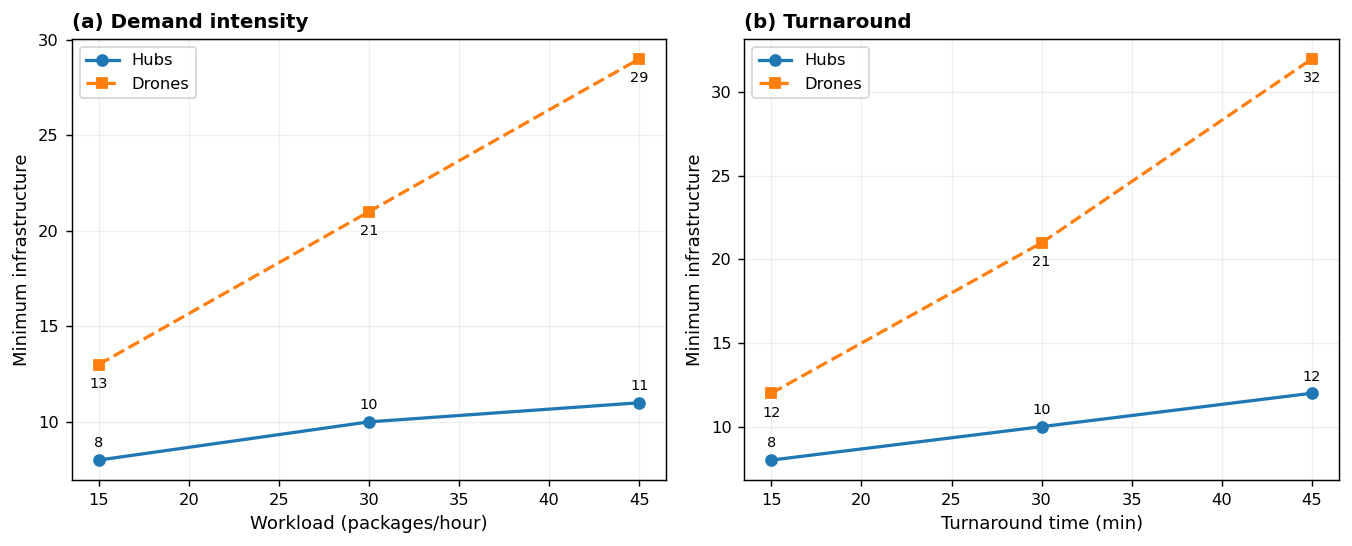

In [33]:
def family_with_baseline(family, xcol):
    g = sensitivity[sensitivity["scenario_family"] == family].copy()
    return pd.concat([g, baseline_sens], ignore_index=True).drop_duplicates(subset=[xcol]).sort_values(xcol)

demand_plot = family_with_baseline("demand", "packages_per_hour")
turn_plot = family_with_baseline("turnaround", "turnaround_min")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))

for ax, data, xcol, xlabel, label in [
    (axes[0], demand_plot, "packages_per_hour", "Workload (packages/hour)", "(a) Demand intensity"),
    (axes[1], turn_plot, "turnaround_min", "Turnaround time (min)", "(b) Turnaround")
]:
    ax.plot(data[xcol], data["minimum_hubs"], marker="o", linewidth=1.8, label="Hubs")
    ax.plot(data[xcol], data["minimum_drones"], marker="s", linewidth=1.8, linestyle="--", label="Drones")
    for _, r in data.iterrows():
        ax.annotate(f'{int(r["minimum_hubs"])}', (r[xcol], r["minimum_hubs"]),
                    xytext=(0,7), textcoords="offset points", ha="center", fontsize=8)
        ax.annotate(f'{int(r["minimum_drones"])}', (r[xcol], r["minimum_drones"]),
                    xytext=(0,-13), textcoords="offset points", ha="center", fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Minimum infrastructure")
    ax.set_title(label, loc="left", fontweight="bold")
    ax.grid(alpha=.18)
    ax.legend()

fig.tight_layout()
savefig(fig, "fig03_throughput_sensitivity_v2")
plt.show()

## Figure 4. Operational sensitivity: response time and battery endurance

This paired figure deliberately contrasts a strongly binding spatial constraint with a nonbinding one under the baseline assumptions.

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig04_spatial_constraint_sensitivity_v2.png


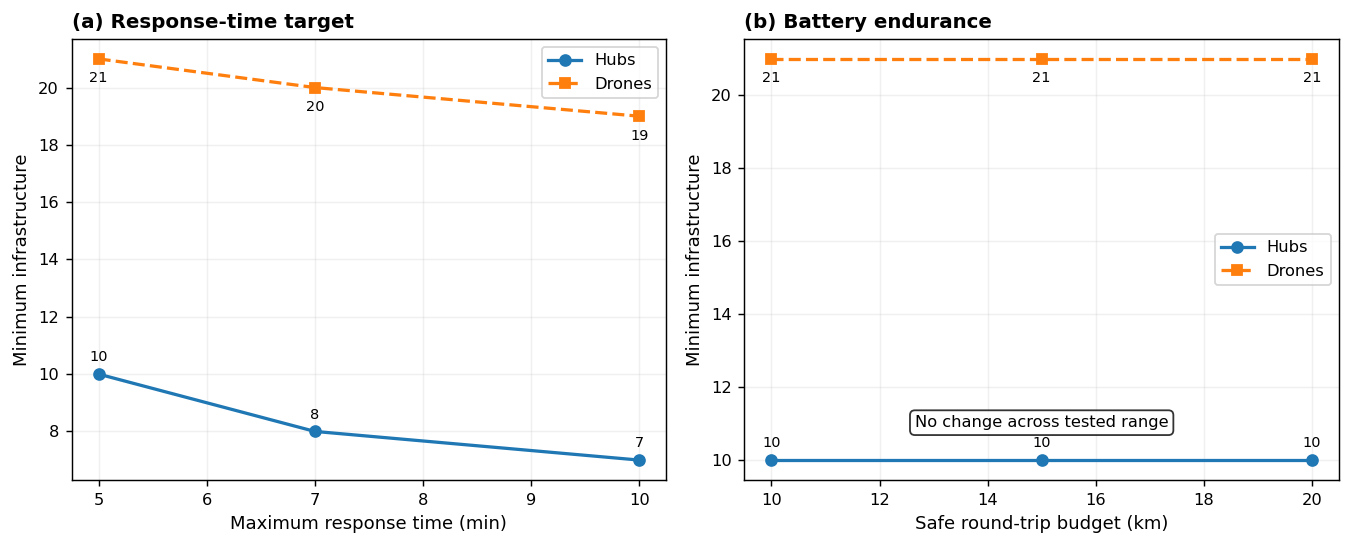

In [34]:
response_plot = family_with_baseline("response", "response_target_min")
battery_plot = family_with_baseline("battery", "safe_roundtrip_km")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))

for ax, data, xcol, xlabel, label in [
    (axes[0], response_plot, "response_target_min", "Maximum response time (min)", "(a) Response-time target"),
    (axes[1], battery_plot, "safe_roundtrip_km", "Safe round-trip budget (km)", "(b) Battery endurance")
]:
    ax.plot(data[xcol], data["minimum_hubs"], marker="o", linewidth=1.8, label="Hubs")
    ax.plot(data[xcol], data["minimum_drones"], marker="s", linewidth=1.8, linestyle="--", label="Drones")
    for _, r in data.iterrows():
        ax.annotate(f'{int(r["minimum_hubs"])}', (r[xcol], r["minimum_hubs"]),
                    xytext=(0,7), textcoords="offset points", ha="center", fontsize=8)
        ax.annotate(f'{int(r["minimum_drones"])}', (r[xcol], r["minimum_drones"]),
                    xytext=(0,-13), textcoords="offset points", ha="center", fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Minimum infrastructure")
    ax.set_title(label, loc="left", fontweight="bold")
    ax.grid(alpha=.18)
    ax.legend()

axes[1].text(.5, .12, "No change across tested range",
             transform=axes[1].transAxes, ha="center", fontsize=9,
             bbox=dict(boxstyle="round,pad=.3", facecolor="white", alpha=.8))

fig.tight_layout()
savefig(fig, "fig04_spatial_constraint_sensitivity_v2")
plt.show()

## Figure 5. Resilience premium

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig05_resilience_premium_v2.png


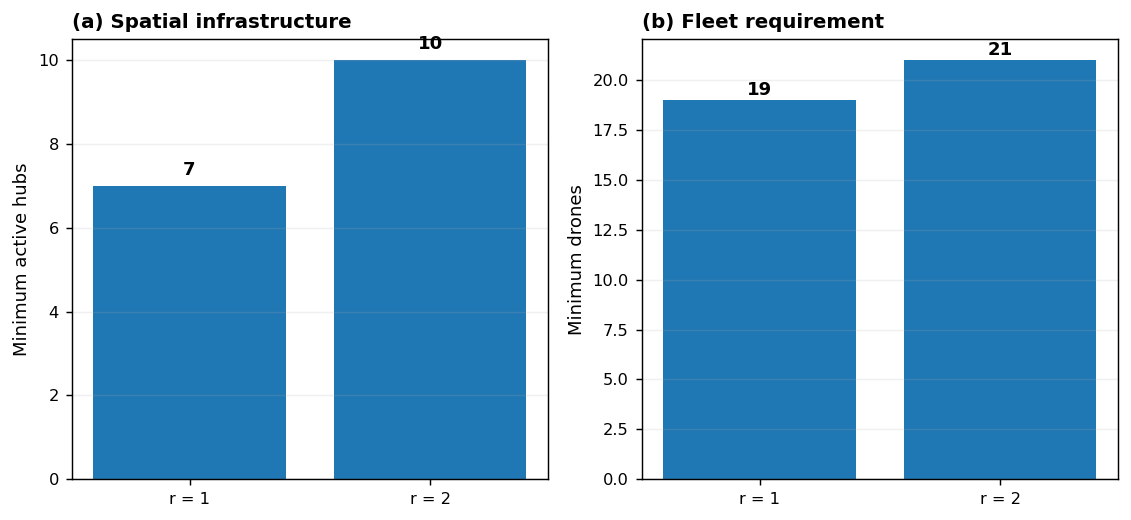

In [35]:
rdat = baseline.sort_values("redundancy").copy()

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.1))

axes[0].bar(["r = 1", "r = 2"], rdat["minimum_hubs"])
axes[0].set_ylabel("Minimum active hubs")
axes[0].set_title("(a) Spatial infrastructure", loc="left", fontweight="bold")
axes[0].grid(axis="y", alpha=.18)

axes[1].bar(["r = 1", "r = 2"], rdat["minimum_drones"])
axes[1].set_ylabel("Minimum drones")
axes[1].set_title("(b) Fleet requirement", loc="left", fontweight="bold")
axes[1].grid(axis="y", alpha=.18)

for ax, vals in [(axes[0], rdat["minimum_hubs"]), (axes[1], rdat["minimum_drones"])]:
    for rect, val in zip(ax.patches, vals):
        ax.text(rect.get_x()+rect.get_width()/2, val+.25, str(int(val)),
                ha="center", fontweight="bold")

fig.tight_layout()
savefig(fig, "fig05_resilience_premium_v2")
plt.show()

## Figure 6. Consolidated sensitivity relative to the resilient baseline

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig06_consolidated_sensitivity_v2.png


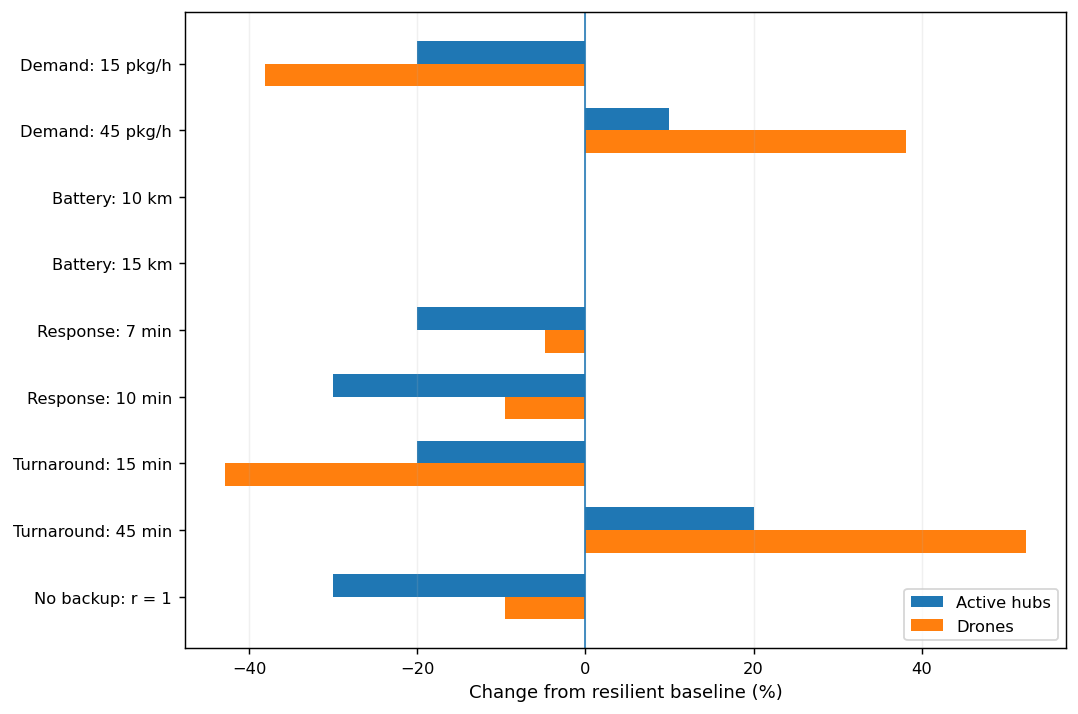

In [36]:
H0 = int(b2["minimum_hubs"])
N0 = int(b2["minimum_drones"])

impact = pd.DataFrame([
    ("Demand: 15 pkg/h", 8, 13),
    ("Demand: 45 pkg/h", 11, 29),
    ("Battery: 10 km", 10, 21),
    ("Battery: 15 km", 10, 21),
    ("Response: 7 min", 8, 20),
    ("Response: 10 min", 7, 19),
    ("Turnaround: 15 min", 8, 12),
    ("Turnaround: 45 min", 12, 32),
    ("No backup: r = 1", 7, 19)
], columns=["Scenario","Hubs","Drones"])

impact["Hub_change_pct"] = 100*(impact["Hubs"]-H0)/H0
impact["Drone_change_pct"] = 100*(impact["Drones"]-N0)/N0

fig, ax = plt.subplots(figsize=(8.4, 5.6))
y = np.arange(len(impact))
h = .34

ax.barh(y-h/2, impact["Hub_change_pct"], h, label="Active hubs")
ax.barh(y+h/2, impact["Drone_change_pct"], h, label="Drones")
ax.axvline(0, linewidth=.9)
ax.set_yticks(y)
ax.set_yticklabels(impact["Scenario"])
ax.set_xlabel("Change from resilient baseline (%)")
ax.grid(axis="x", alpha=.18)
ax.legend(loc="lower right")
ax.invert_yaxis()

fig.tight_layout()
savefig(fig, "fig06_consolidated_sensitivity_v2")
plt.show()

impact.to_csv(TABLE_DIR/"table_consolidated_sensitivity_v2.csv", index=False)

## 7. Load spatial data and resilient baseline solution

In [37]:
zones_file = PROCESSED_DIR / "hajj_analytical_zones_v1.gpkg"
demand_file = PROCESSED_DIR / "hajj_demand_locations_500m_v1.gpkg"

zones = gpd.read_file(zones_file).to_crs(4326)
demand_grid = gpd.read_file(demand_file).to_crs(4326)

ZONE_COLORS = {
    "Haram_Makkah": "tab:blue",
    "Mina": "tab:green",
    "Muzdalifah": "tab:purple",
    "Arafat": "tab:red"
}

def zone_boundaries(ax):
    for _, row in zones.iterrows():
        gpd.GeoSeries([row.geometry], crs=zones.crs).boundary.plot(
            ax=ax, color=ZONE_COLORS.get(row["zone"], "0.4"), linewidth=1.4
        )

baseline_id = baseline_sens.iloc[0]["scenario_id"]

resilient_hubs = hub_fleet[hub_fleet["scenario_id"] == baseline_id].copy()
resilient_flows = flows[flows["scenario_id"] == baseline_id].copy()

if len(resilient_hubs) != 10:
    raise ValueError(f"Expected 10 resilient baseline hubs, found {len(resilient_hubs)}")

print("Baseline scenario:", baseline_id)
print("Hubs:", len(resilient_hubs))
print("Drones:", int(resilient_hubs["drones"].sum()))
print("Package flows:", len(resilient_flows))

Baseline scenario: S02
Hubs: 10
Drones: 21
Package flows: 30


## Figure 7. Baseline resilient hub-and-fleet configuration

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig07_resilient_network_map_v2.png


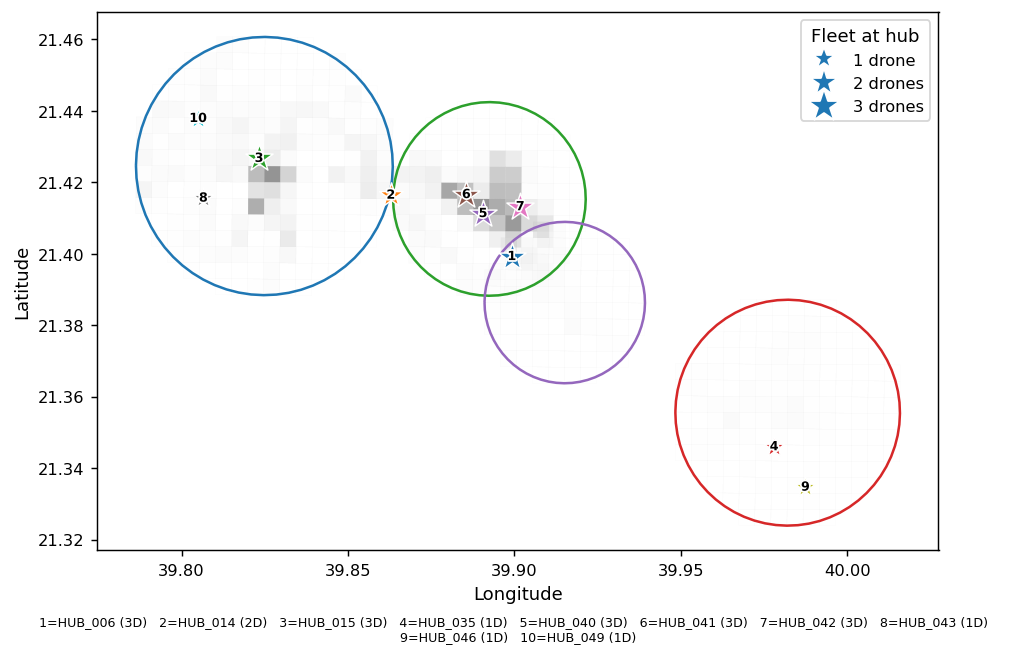

In [38]:
fig, ax = plt.subplots(figsize=(8.0, 6.3))

demand_grid.plot(
    ax=ax, column="proxy_demand_weight", cmap="Greys",
    vmin=1, vmax=5, linewidth=.05, edgecolor=".82", alpha=.42
)
zone_boundaries(ax)

# Use numbered hub labels to avoid long overlapping text.
for k, (_, hrow) in enumerate(resilient_hubs.iterrows(), start=1):
    size = 85 + 55*int(hrow["drones"])
    ax.scatter(hrow["longitude"], hrow["latitude"], s=size, marker="*",
               edgecolors="white", linewidths=.8, zorder=5)
    txt = ax.annotate(str(k), (hrow["longitude"], hrow["latitude"]),
                      ha="center", va="center", fontsize=7, fontweight="bold", zorder=6)
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Explicit fleet-size legend
fleet_handles = [
    Line2D([0],[0], marker="*", linestyle="None", markersize=10+3*n,
           markeredgecolor="white", label=f"{n} drone{'s' if n>1 else ''}")
    for n in sorted(resilient_hubs["drones"].unique())
]
ax.legend(handles=fleet_handles, title="Fleet at hub", loc="upper right")

# Numbered hub key below plot
key = resilient_hubs.reset_index(drop=True).copy()
key["Map label"] = np.arange(1, len(key)+1)
key_text = "   ".join(
    f'{int(r["Map label"])}={r["hub_id"]} ({int(r["drones"])}D)'
    for _, r in key.iterrows()
)
ax.text(.5, -.12, key_text, transform=ax.transAxes, ha="center", va="top", fontsize=7, wrap=True)

fig.tight_layout()
savefig(fig, "fig07_resilient_network_map_v2")
plt.show()

## Figure 8. Baseline resilient package assignments

Saved: hajj_drone_project\outputs\figures\operational_paper_v2\fig08_resilient_package_flows_v2.png


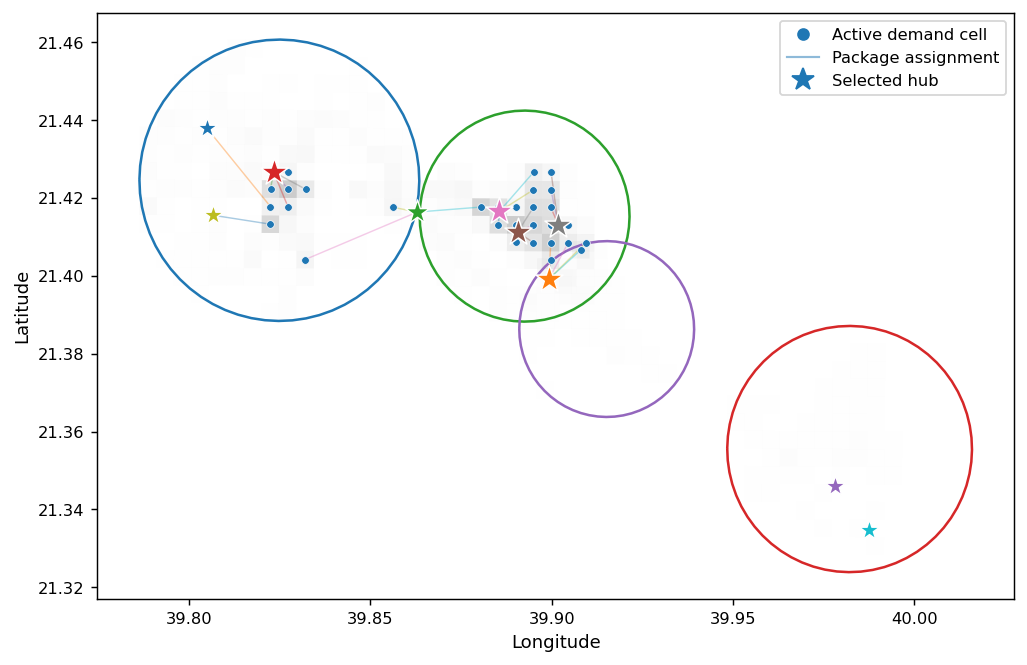

In [39]:
hub_lookup = resilient_hubs.set_index("hub_id")
demand_lookup = demand_grid.set_index("demand_point_id")

fig, ax = plt.subplots(figsize=(8.0, 6.3))

demand_grid.plot(
    ax=ax, column="proxy_demand_weight", cmap="Greys",
    vmin=1, vmax=5, linewidth=0, alpha=.20
)
zone_boundaries(ax)

# Plot only realized package-flow links.
for _, row in resilient_flows.iterrows():
    if row["hub_id"] not in hub_lookup.index or row["demand_point_id"] not in demand_lookup.index:
        continue
    hrow = hub_lookup.loc[row["hub_id"]]
    drow = demand_lookup.loc[row["demand_point_id"]]
    ax.plot([drow["centroid_lon"], hrow["longitude"]],
            [drow["centroid_lat"], hrow["latitude"]],
            linewidth=.8, alpha=.38, zorder=2)

# Active demand points
active_ids = resilient_flows["demand_point_id"].unique()
active = demand_grid[demand_grid["demand_point_id"].isin(active_ids)]
ax.scatter(active["centroid_lon"], active["centroid_lat"],
           s=18, marker="o", edgecolors="white", linewidths=.4, zorder=4)

# Hubs
for _, hrow in resilient_hubs.iterrows():
    ax.scatter(hrow["longitude"], hrow["latitude"],
               s=85+55*int(hrow["drones"]), marker="*",
               edgecolors="white", linewidths=.8, zorder=5)

legend_handles = [
    Line2D([0],[0], marker="o", linestyle="None", markersize=6, label="Active demand cell"),
    Line2D([0],[0], linewidth=1.2, alpha=.5, label="Package assignment"),
    Line2D([0],[0], marker="*", linestyle="None", markersize=13, label="Selected hub")
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.tight_layout()
savefig(fig, "fig08_resilient_package_flows_v2")
plt.show()

## 9. Export publication tables and figure inventory

In [40]:
baseline_table = baseline[[
    "redundancy","minimum_hubs","minimum_drones",
    "mean_response_min","max_response_min",
    "mean_oneway_distance_km","max_oneway_distance_km"
]].copy()

baseline_table.to_csv(TABLE_DIR/"table_baseline_operational_resilient_v2.csv", index=False)

sensitivity[[
    "scenario_id","scenario_family","packages_per_hour","safe_roundtrip_km",
    "response_target_min","turnaround_min","redundancy",
    "minimum_hubs","minimum_drones","mean_response_min","max_response_min",
    "mean_oneway_distance_km","max_oneway_distance_km"
]].to_csv(TABLE_DIR/"table_sensitivity_results_v2.csv", index=False)

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print("-", p.name)

print("\nFigure folder:")
print(FIG_DIR.resolve())

print("\nWhen all figures look correct, ZIP this folder and share it for final visual review.")


Generated figures:
- fig01_progressive_infrastructure_v2.png
- fig02_fixed_p_resilience_v2.png
- fig03_throughput_sensitivity_v2.png
- fig04_spatial_constraint_sensitivity_v2.png
- fig05_resilience_premium_v2.png
- fig06_consolidated_sensitivity_v2.png
- fig07_resilient_network_map_v2.png
- fig08_resilient_package_flows_v2.png

Figure folder:
C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\outputs\figures\operational_paper_v2

When all figures look correct, ZIP this folder and share it for final visual review.


# Review checkpoint

Do not begin manuscript rewriting yet.

After running this notebook, inspect all eight revised PNG figures in:

`outputs/figures/operational_paper_v2/`

Then ZIP that folder and share it for visual review. The manuscript figure set will be selected only after the revised outputs are approved.

# Publication Figure Set V3

This section supersedes the V2 figure cells above. It keeps the same saved optimization results but applies the final visual-review corrections:

- removes explanatory prose from inside Figure 1;
- fixes label overlap;
- explicitly marks infeasible fixed-$p$ configurations in Figure 2;
- simplifies the battery null-effect annotation;
- adds percentage labels and visual grouping to the consolidated sensitivity figure;
- creates an interactive Folium resilient-solution map;
- redesigns the assignment map so assignment links are colored by serving hub;
- exports a clean hub key table;
- provides an automatic Folium + analytical side-by-side compositor.

Run this section after the V2 data-loading and spatial-data cells have been run.

In [41]:
# V3 output folders
V3_FIG_DIR = PROJECT_ROOT / "outputs" / "figures" / "operational_paper_v3"
V3_TABLE_DIR = PROJECT_ROOT / "outputs" / "reports" / "operational_paper_v3"
V3_MAP_DIR = PROJECT_ROOT / "outputs" / "maps" / "operational_paper_v3"
V3_FOLIUM_PANEL_DIR = V3_FIG_DIR / "folium_panels"
V3_COMBINED_DIR = V3_FIG_DIR / "combined"

for folder in [V3_FIG_DIR,V3_TABLE_DIR,V3_MAP_DIR,V3_FOLIUM_PANEL_DIR,V3_COMBINED_DIR]:
    folder.mkdir(parents=True,exist_ok=True)

def savefig_v3(fig,name):
    png=V3_FIG_DIR/f"{name}.png"
    pdf=V3_FIG_DIR/f"{name}.pdf"
    fig.savefig(png,dpi=600,bbox_inches="tight",facecolor="white")
    fig.savefig(pdf,bbox_inches="tight",facecolor="white")
    print("Saved:",png)
    return png

## V3 Figure 1. Progressive infrastructure requirements

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig01_progressive_infrastructure_v3.png


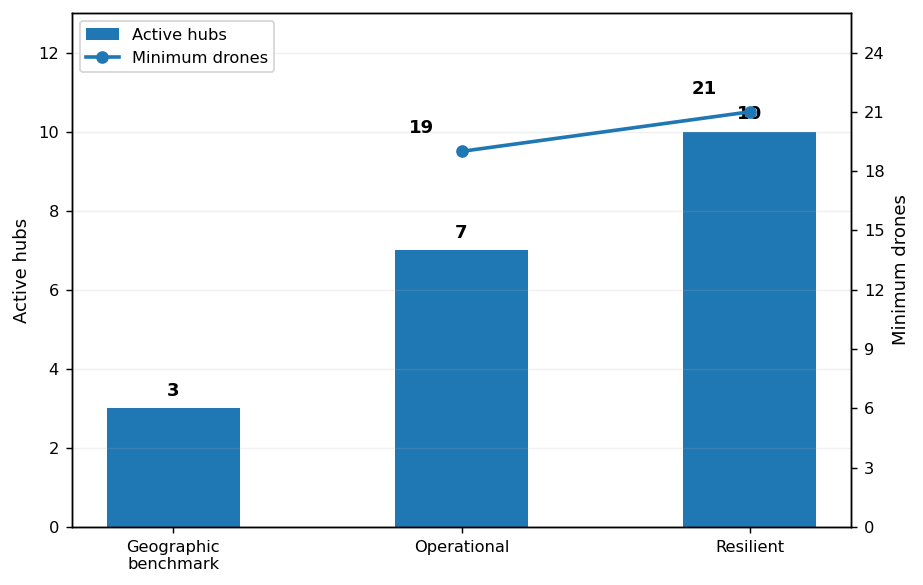

In [42]:
fig,ax1=plt.subplots(figsize=(7.2,4.6))
x=np.arange(3)
stages=["Geographic\nbenchmark","Operational","Resilient"]
hvals=[3,int(b1["minimum_hubs"]),int(b2["minimum_hubs"])]
dvals=[np.nan,int(b1["minimum_drones"]),int(b2["minimum_drones"])]

bars=ax1.bar(x,hvals,width=.46,label="Active hubs")
ax1.set_ylabel("Active hubs")
ax1.set_xticks(x); ax1.set_xticklabels(stages)
ax1.set_ylim(0,13)
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.grid(axis="y",alpha=.18)

for rect,val in zip(bars,hvals):
    ax1.annotate(str(val),(rect.get_x()+rect.get_width()/2,val),
                 xytext=(0,7),textcoords="offset points",
                 ha="center",fontweight="bold")

ax2=ax1.twinx()
line=ax2.plot(x[1:],dvals[1:],marker="o",linewidth=2,label="Minimum drones")[0]
ax2.set_ylabel("Minimum drones")
ax2.set_ylim(0,26)
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

# Offset drone labels away from bar labels.
ax2.annotate(str(dvals[1]),(x[1],dvals[1]),xytext=(-15,10),
             textcoords="offset points",ha="right",fontweight="bold")
ax2.annotate(str(dvals[2]),(x[2],dvals[2]),xytext=(-18,10),
             textcoords="offset points",ha="right",fontweight="bold")

ax1.legend([bars,line],["Active hubs","Minimum drones"],loc="upper left")
fig.tight_layout()
savefig_v3(fig,"fig01_progressive_infrastructure_v3")
plt.show()

## V3 Figure 2. Fixed-hub feasibility and resilience premium

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig02_fixed_p_resilience_v3.png


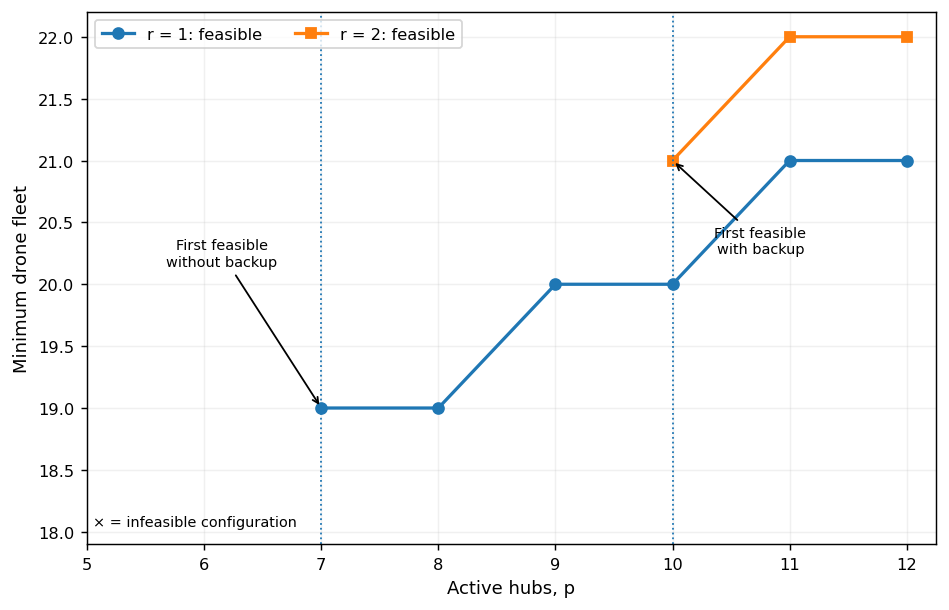

In [43]:
fig,ax=plt.subplots(figsize=(7.4,4.8))

for r,marker in [(1,"o"),(2,"s")]:
    g=resilience[resilience["redundancy"]==r].sort_values("p")
    feasible=g[g["termination"]=="optimal"]
    infeasible=g[g["termination"]!="optimal"]

    ax.plot(feasible["p"],feasible["minimum_drones"],
            marker=marker,linewidth=1.8,label=f"r = {r}: feasible")

    # Put infeasible markers on a dedicated lower band.
    y_inf=18.45 if r==1 else 18.25
    if len(infeasible):
        ax.scatter(infeasible["p"],np.repeat(y_inf,len(infeasible)),
                   marker="x",s=55,label=f"r = {r}: infeasible")

ax.axvline(7,linestyle=":",linewidth=1)
ax.axvline(10,linestyle=":",linewidth=1)

ax.annotate("First feasible\nwithout backup",
            xy=(7,19),xytext=(6.15,20.15),
            arrowprops=dict(arrowstyle="->"),ha="center",fontsize=8)

ax.annotate("First feasible\nwith backup",
            xy=(10,21),xytext=(10.75,20.25),
            arrowprops=dict(arrowstyle="->"),ha="center",fontsize=8)

ax.text(5.05,18.05,"× = infeasible configuration",fontsize=8)
ax.set_xlabel("Active hubs, p")
ax.set_ylabel("Minimum drone fleet")
ax.set_xticks(range(5,13))
ax.set_ylim(17.9,22.2)
ax.grid(alpha=.18)
ax.legend(ncol=2,loc="upper left")
fig.tight_layout()

savefig_v3(fig,"fig02_fixed_p_resilience_v3")
plt.show()

## V3 Figure 3. Throughput sensitivity

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig03_throughput_sensitivity_v3.png


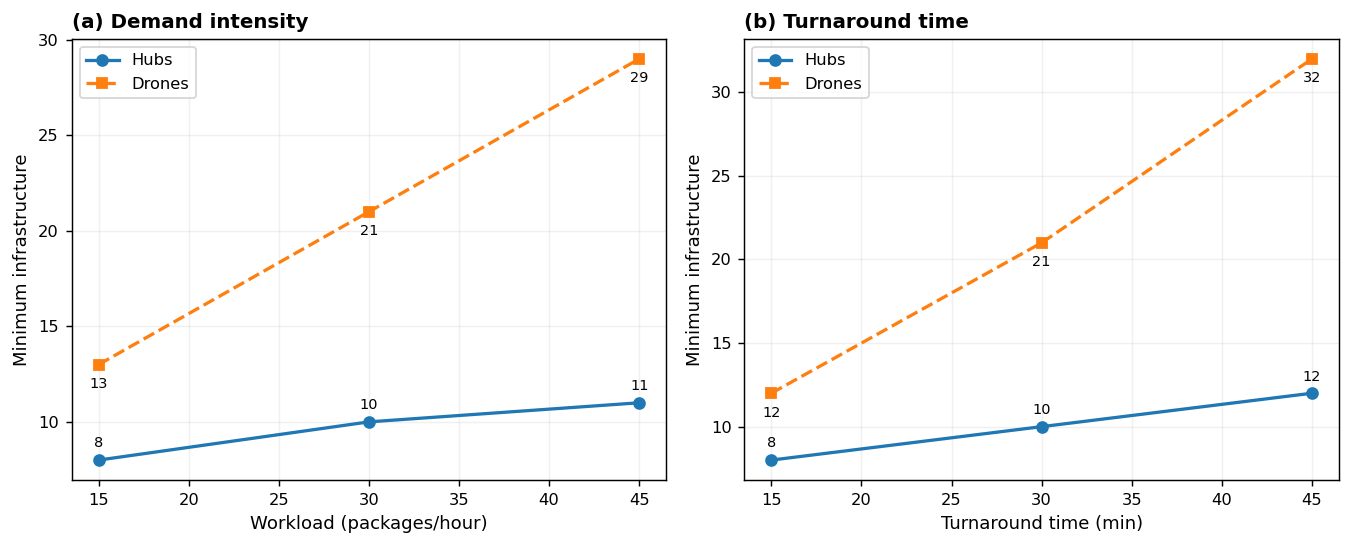

In [44]:
# Retain the successful V2 design with slightly cleaner labels.
demand_plot=family_with_baseline("demand","packages_per_hour")
turn_plot=family_with_baseline("turnaround","turnaround_min")

fig,axes=plt.subplots(1,2,figsize=(10.5,4.3))

for ax,data,xcol,xlabel,title in [
    (axes[0],demand_plot,"packages_per_hour","Workload (packages/hour)","(a) Demand intensity"),
    (axes[1],turn_plot,"turnaround_min","Turnaround time (min)","(b) Turnaround time")
]:
    ax.plot(data[xcol],data["minimum_hubs"],marker="o",linewidth=1.8,label="Hubs")
    ax.plot(data[xcol],data["minimum_drones"],marker="s",linestyle="--",linewidth=1.8,label="Drones")
    for _,r in data.iterrows():
        ax.annotate(str(int(r["minimum_hubs"])),(r[xcol],r["minimum_hubs"]),
                    xytext=(0,7),textcoords="offset points",ha="center",fontsize=8)
        ax.annotate(str(int(r["minimum_drones"])),(r[xcol],r["minimum_drones"]),
                    xytext=(0,-13),textcoords="offset points",ha="center",fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Minimum infrastructure")
    ax.set_title(title,loc="left",fontweight="bold")
    ax.grid(alpha=.18)
    ax.legend()

fig.tight_layout()
savefig_v3(fig,"fig03_throughput_sensitivity_v3")
plt.show()

## V3 Figure 4. Response-time versus battery sensitivity

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig04_spatial_constraint_sensitivity_v3.png


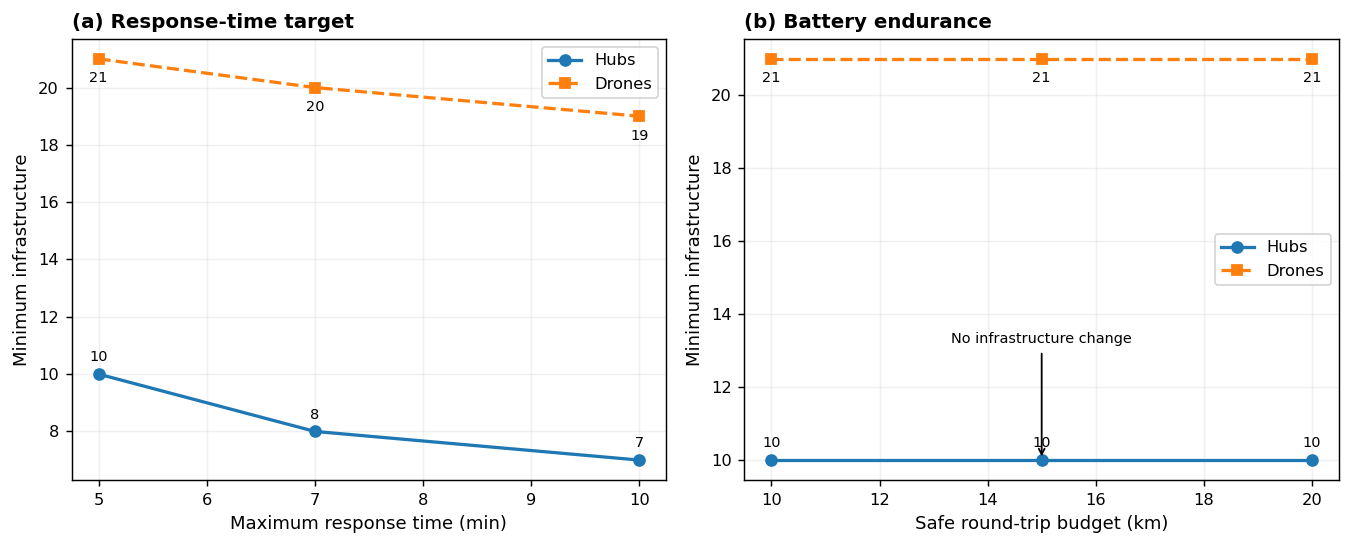

In [45]:
response_plot=family_with_baseline("response","response_target_min")
battery_plot=family_with_baseline("battery","safe_roundtrip_km")

fig,axes=plt.subplots(1,2,figsize=(10.5,4.3))

for ax,data,xcol,xlabel,title in [
    (axes[0],response_plot,"response_target_min","Maximum response time (min)","(a) Response-time target"),
    (axes[1],battery_plot,"safe_roundtrip_km","Safe round-trip budget (km)","(b) Battery endurance")
]:
    ax.plot(data[xcol],data["minimum_hubs"],marker="o",linewidth=1.8,label="Hubs")
    ax.plot(data[xcol],data["minimum_drones"],marker="s",linestyle="--",linewidth=1.8,label="Drones")
    for _,r in data.iterrows():
        ax.annotate(str(int(r["minimum_hubs"])),(r[xcol],r["minimum_hubs"]),
                    xytext=(0,7),textcoords="offset points",ha="center",fontsize=8)
        ax.annotate(str(int(r["minimum_drones"])),(r[xcol],r["minimum_drones"]),
                    xytext=(0,-13),textcoords="offset points",ha="center",fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Minimum infrastructure")
    ax.set_title(title,loc="left",fontweight="bold")
    ax.grid(alpha=.18)
    ax.legend()

axes[1].annotate("No infrastructure change",
                 xy=(15,10),xytext=(15,13.2),
                 arrowprops=dict(arrowstyle="->"),ha="center",fontsize=8)

fig.tight_layout()
savefig_v3(fig,"fig04_spatial_constraint_sensitivity_v3")
plt.show()

## V3 Figure 5. Resilience premium

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig05_resilience_premium_v3.png


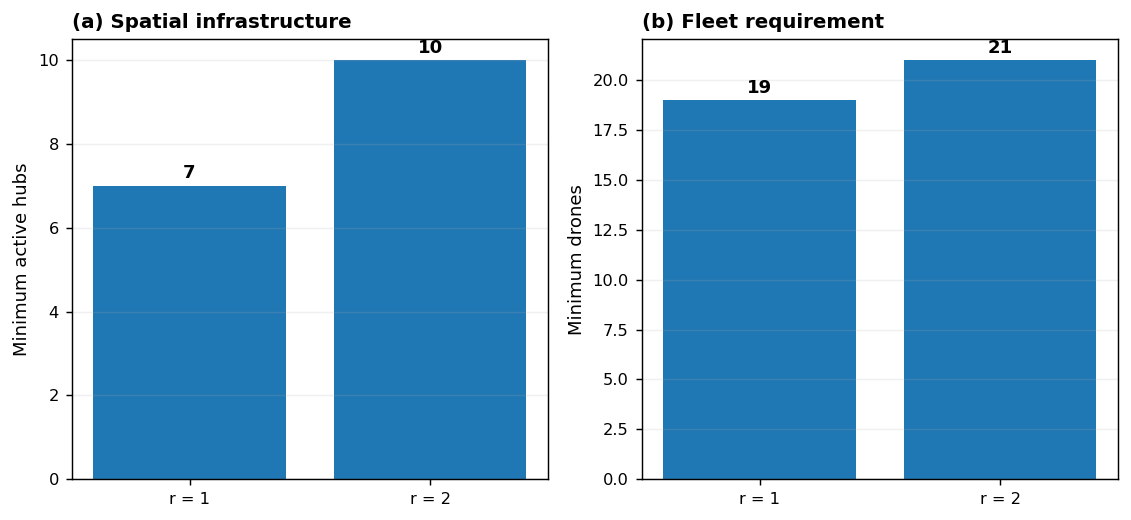

In [46]:
rdat=baseline.sort_values("redundancy")
fig,axes=plt.subplots(1,2,figsize=(8.8,4.1))

for ax,col,ylabel,title in [
    (axes[0],"minimum_hubs","Minimum active hubs","(a) Spatial infrastructure"),
    (axes[1],"minimum_drones","Minimum drones","(b) Fleet requirement")
]:
    bars=ax.bar(["r = 1","r = 2"],rdat[col])
    ax.set_ylabel(ylabel)
    ax.set_title(title,loc="left",fontweight="bold")
    ax.grid(axis="y",alpha=.18)
    for rect,val in zip(bars,rdat[col]):
        ax.annotate(str(int(val)),(rect.get_x()+rect.get_width()/2,val),
                    xytext=(0,4),textcoords="offset points",
                    ha="center",fontweight="bold")

fig.tight_layout()
savefig_v3(fig,"fig05_resilience_premium_v3")
plt.show()

## V3 Figure 6. Consolidated operational sensitivity

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig06_consolidated_sensitivity_v3.png


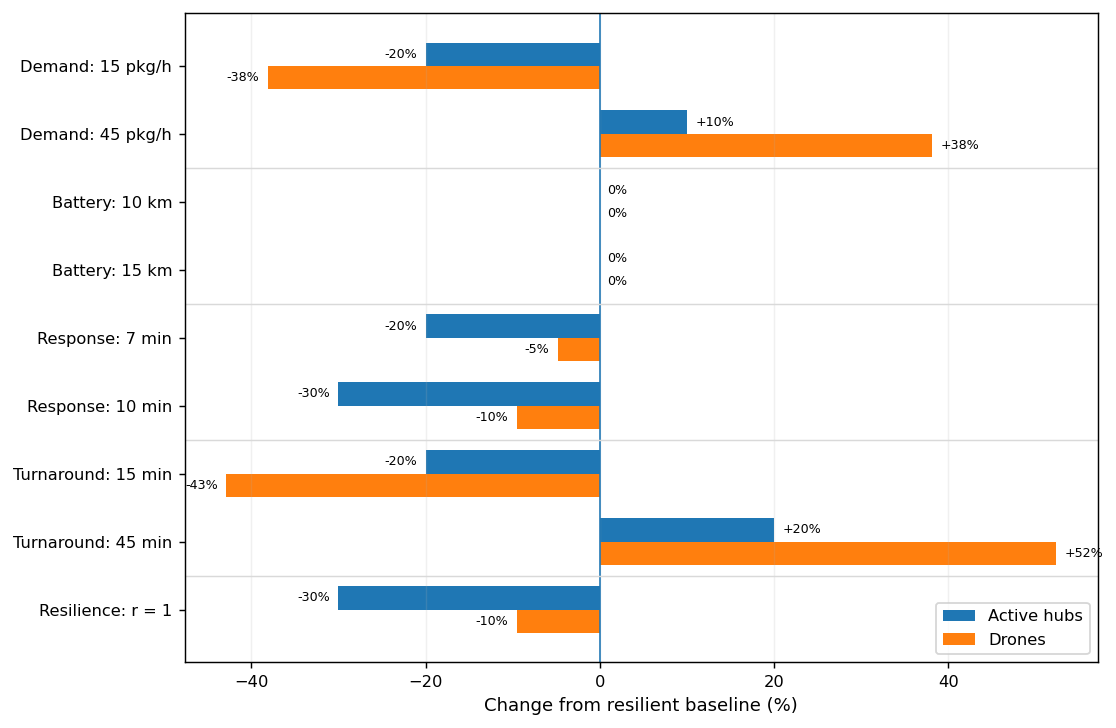

In [47]:
H0=int(b2["minimum_hubs"]); N0=int(b2["minimum_drones"])

impact=pd.DataFrame([
    ("Demand","15 pkg/h",8,13),
    ("Demand","45 pkg/h",11,29),
    ("Battery","10 km",10,21),
    ("Battery","15 km",10,21),
    ("Response","7 min",8,20),
    ("Response","10 min",7,19),
    ("Turnaround","15 min",8,12),
    ("Turnaround","45 min",12,32),
    ("Resilience","r = 1",7,19)
],columns=["Family","Setting","Hubs","Drones"])

impact["Hub_change_pct"]=100*(impact["Hubs"]-H0)/H0
impact["Drone_change_pct"]=100*(impact["Drones"]-N0)/N0
impact["Label"]=impact["Family"]+": "+impact["Setting"]

fig,ax=plt.subplots(figsize=(8.7,5.7))
y=np.arange(len(impact)); h=.34
bh=ax.barh(y-h/2,impact["Hub_change_pct"],h,label="Active hubs")
bd=ax.barh(y+h/2,impact["Drone_change_pct"],h,label="Drones")
ax.axvline(0,linewidth=.9)
ax.set_yticks(y); ax.set_yticklabels(impact["Label"])
ax.set_xlabel("Change from resilient baseline (%)")
ax.grid(axis="x",alpha=.18)
ax.legend(loc="lower right")
ax.invert_yaxis()

def label_bar(bar,val):
    if abs(val)<0.05:
        ax.text(.8,bar.get_y()+bar.get_height()/2,"0%",va="center",fontsize=7)
    else:
        offset=1.0 if val>0 else -1.0
        ha="left" if val>0 else "right"
        ax.text(val+offset,bar.get_y()+bar.get_height()/2,
                f"{val:+.0f}%",va="center",ha=ha,fontsize=7)

for bar,val in zip(bh,impact["Hub_change_pct"]): label_bar(bar,val)
for bar,val in zip(bd,impact["Drone_change_pct"]): label_bar(bar,val)

# Family separators
for pos in [1.5,3.5,5.5,7.5]:
    ax.axhline(pos,color=".85",linewidth=.8)

fig.tight_layout()
savefig_v3(fig,"fig06_consolidated_sensitivity_v3")
plt.show()

impact.to_csv(V3_TABLE_DIR/"table_consolidated_sensitivity_v3.csv",index=False)

## V3 Figure 7. Interactive resilient baseline map

This Folium map provides geographic context for the 10-hub, 21-drone resilient baseline.

Hub marker size is represented in the popup/tooltip through the reported drone count. Analytical Hajj-zone overlays are retained. The HTML is intended for the GitHub repository and for capturing the left-hand panel of the final composite figure.

In [48]:
import folium
from branca.element import Element

m=folium.Map(
    location=[float(resilient_hubs["latitude"].mean()),
              float(resilient_hubs["longitude"].mean())],
    zoom_start=11,
    control_scale=True
)

# Zones
zg=folium.FeatureGroup(name="Hajj analytical zones",show=True).add_to(m)
for _,r in zones.iterrows():
    c=ZONE_COLORS.get(r["zone"],"#777777")
    folium.GeoJson(
        r.geometry.__geo_interface__,
        style_function=lambda feature,c=c:{
            "color":c,"weight":2,"fillColor":c,"fillOpacity":.05
        },
        tooltip=r["zone"].replace("_"," ")
    ).add_to(zg)

# Demand surface
dg=folium.FeatureGroup(name="Proxy-demand cells",show=True).add_to(m)
for _,r in demand_grid.iterrows():
    w=float(r["proxy_demand_weight"])
    opacity=.08 + .35*(w-1)/4
    folium.GeoJson(
        r.geometry.__geo_interface__,
        style_function=lambda feature,opacity=opacity:{
            "color":"#777777","weight":.25,
            "fillColor":"#555555","fillOpacity":opacity
        },
        tooltip=f'{r["demand_point_id"]} | proxy weight {w:.2f}'
    ).add_to(dg)

# Hubs
hg=folium.FeatureGroup(name="Selected resilient hubs",show=True).add_to(m)
for _,hrow in resilient_hubs.iterrows():
    folium.CircleMarker(
        [hrow["latitude"],hrow["longitude"]],
        radius=6+2*int(hrow["drones"]),
        color="#111111",weight=1.2,
        fill=True,fill_color="#111111",fill_opacity=.85,
        tooltip=f'{hrow["hub_id"]}: {int(hrow["drones"])} drone(s)',
        popup=folium.Popup(
            f'<b>{hrow["hub_id"]}</b><br>'
            f'{hrow.get("hub_name","")}<br>'
            f'Zone: {hrow["hajj_zone"]}<br>'
            f'Fleet: {int(hrow["drones"])} drone(s)',max_width=360
        )
    ).add_to(hg)

folium.LayerControl(collapsed=False).add_to(m)

legend_html='''<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
background:white;border:2px solid #777;border-radius:6px;padding:10px 14px;font-size:12px">
<b>Baseline resilient network</b><br>
10 active hubs<br>21 drones<br>
Marker size = drones stationed at hub
</div>'''
m.get_root().html.add_child(Element(legend_html))

folium_path=V3_MAP_DIR/"resilient_baseline_10hub_21drone_folium.html"
m.save(folium_path)
print("Saved:",folium_path)
m

Saved: hajj_drone_project\outputs\maps\operational_paper_v3\resilient_baseline_10hub_21drone_folium.html


## V3 Figure 8. Analytical resilient assignment map

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\fig08_resilient_assignments_v3.png


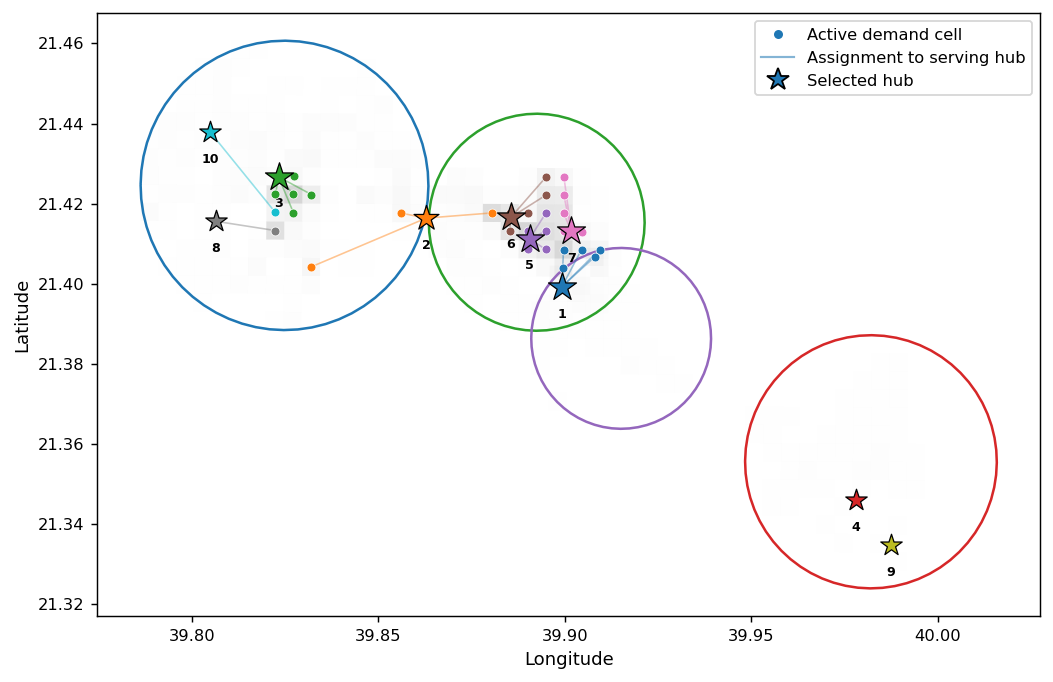

,Map label,hub_id,hub_name,hajj_zone,drones
0,1,HUB_006,Armed Forces Hospital,Mina,3
1,2,HUB_014,مستوصف العبير,Greater_Makkah,2
2,3,HUB_015,Al Haram Emergency Hospital,Haram_Makkah,3
3,4,HUB_035,MarkazSihhiMawsimiRaqmSittat'Ashar,Arafat,1
4,5,HUB_040,Mina Al-Share’a Al-Jadeed Hospital,Mina,3
5,6,HUB_041,مركز هيئة الهلال الأحمر - منى,Mina,3
6,7,HUB_042,Mina Al-Wadi Hospital,Mina,3
7,8,HUB_043,Hospital Shifa,Haram_Makkah,1
8,9,HUB_046,Eastern Arafat Hospital,Arafat,1
9,10,HUB_049,SHIFA AL BARAKA MEDICAL CENTER,Haram_Makkah,1


In [49]:
# Stable categorical assignment colors, one per selected hub.
hub_ids=list(resilient_hubs["hub_id"])
cmap=plt.get_cmap("tab10")
hub_color={hid:cmap(i%10) for i,hid in enumerate(hub_ids)}

hub_lookup=resilient_hubs.set_index("hub_id")
demand_lookup=demand_grid.set_index("demand_point_id")

fig,ax=plt.subplots(figsize=(8.2,6.4))

demand_grid.plot(ax=ax,column="proxy_demand_weight",cmap="Greys",
                 vmin=1,vmax=5,linewidth=0,alpha=.16)
zone_boundaries(ax)

# Assignment links and active demand cells colored by serving hub.
for _,row in resilient_flows.iterrows():
    hid=row["hub_id"]; did=row["demand_point_id"]
    if hid not in hub_lookup.index or did not in demand_lookup.index:
        continue
    hrow=hub_lookup.loc[hid]; drow=demand_lookup.loc[did]
    c=hub_color[hid]
    ax.plot([drow["centroid_lon"],hrow["longitude"]],
            [drow["centroid_lat"],hrow["latitude"]],
            color=c,linewidth=.9,alpha=.45,zorder=2)
    ax.scatter(drow["centroid_lon"],drow["centroid_lat"],
               s=24,color=c,edgecolors="white",linewidths=.4,zorder=4)

# Selected hubs use matching assignment colors and fleet-scaled stars.
for _,hrow in resilient_hubs.iterrows():
    hid=hrow["hub_id"]; c=hub_color[hid]
    ax.scatter(hrow["longitude"],hrow["latitude"],
               s=100+55*int(hrow["drones"]),marker="*",
               color=c,edgecolors="black",linewidths=.7,zorder=6)

# Compact numbered key
key=resilient_hubs.reset_index(drop=True).copy()
key["Map label"]=np.arange(1,len(key)+1)
for _,r in key.iterrows():
    ax.annotate(str(int(r["Map label"])),(r["longitude"],r["latitude"]),
                xytext=(0,-17),textcoords="offset points",ha="center",
                fontsize=7,fontweight="bold")

legend_handles=[
    Line2D([0],[0],marker="o",linestyle="None",markersize=6,
           markeredgecolor="white",label="Active demand cell"),
    Line2D([0],[0],linewidth=1.2,alpha=.55,label="Assignment to serving hub"),
    Line2D([0],[0],marker="*",linestyle="None",markersize=13,
           markeredgecolor="black",label="Selected hub")
]
ax.legend(handles=legend_handles,loc="upper right")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

fig.tight_layout()
analytical_path=savefig_v3(fig,"fig08_resilient_assignments_v3")
plt.show()

# Export the hub key as a publication table.
hub_key=key[["Map label","hub_id","hub_name","hajj_zone","drones"]].copy()
hub_key.to_csv(V3_TABLE_DIR/"table_resilient_hub_key_v3.csv",index=False)
display(hub_key)

## V3 Figure 9. Side-by-side geographic and analytical solution

After opening the Folium HTML and capturing a clean screenshot, save it as:

`resilient_baseline_folium.png`

inside:

`outputs/figures/operational_paper_v3/folium_panels/`

Then run the following cell. It creates the final publication composite automatically.

The labels are intentionally large and use only `(a)` and `(b)`; panel explanations should be placed in the manuscript caption.

In [50]:
from PIL import Image,ImageDraw,ImageFont

def _large_font(size=72):
    candidates=[
        "arialbd.ttf",
        "arial.ttf",
        "DejaVuSans-Bold.ttf"
    ]
    for f in candidates:
        try:
            return ImageFont.truetype(f,size)
        except Exception:
            pass
    return ImageFont.load_default()

def combine_solution_panels(
    folium_filename="resilient_baseline_folium.png",
    analytical_filename="fig08_resilient_assignments_v3.png",
    output_name="fig09_resilient_solution_composite_v3"
):
    left_path=V3_FOLIUM_PANEL_DIR/folium_filename
    right_path=V3_FIG_DIR/analytical_filename

    if not left_path.exists():
        print("Folium screenshot not found:",left_path)
        print("Capture the generated HTML map and save it with the expected filename.")
        return None

    if not right_path.exists():
        raise FileNotFoundError(right_path)

    left=Image.open(left_path).convert("RGB")
    right=Image.open(right_path).convert("RGB")

    target_h=max(left.height,right.height)
    def resize_h(im,h):
        w=round(im.width*h/im.height)
        return im.resize((w,h),Image.Resampling.LANCZOS)

    left=resize_h(left,target_h)
    right=resize_h(right,target_h)

    top=105
    gap=28
    margin=20
    canvas=Image.new("RGB",
        (left.width+right.width+gap+2*margin,target_h+top+2*margin),
        "white")

    lx=margin; rx=margin+left.width+gap
    canvas.paste(left,(lx,top+margin))
    canvas.paste(right,(rx,top+margin))

    draw=ImageDraw.Draw(canvas)
    font=_large_font(72)
    draw.text((lx+18,18),"(a)",fill="black",font=font)
    draw.text((rx+18,18),"(b)",fill="black",font=font)

    png=V3_COMBINED_DIR/f"{output_name}.png"
    pdf=V3_COMBINED_DIR/f"{output_name}.pdf"
    canvas.save(png,dpi=(600,600))
    canvas.save(pdf,resolution=600.0)
    print("Saved:",png)
    return png

combine_solution_panels()

Saved: hajj_drone_project\outputs\figures\operational_paper_v3\combined\fig09_resilient_solution_composite_v3.png


WindowsPath('hajj_drone_project/outputs/figures/operational_paper_v3/combined/fig09_resilient_solution_composite_v3.png')

## V3 final export inventory

In [51]:
print("V3 analytical figures:")
for p in sorted(V3_FIG_DIR.glob("*.png")):
    print("-",p.name)

print("\nInteractive maps:")
for p in sorted(V3_MAP_DIR.glob("*.html")):
    print("-",p.name)

print("\nCombined figures:")
for p in sorted(V3_COMBINED_DIR.glob("*.png")):
    print("-",p.name)

print("\nTables:")
for p in sorted(V3_TABLE_DIR.glob("*.csv")):
    print("-",p.name)

print("\nNext step:")
print("1. Capture resilient_baseline_10hub_21drone_folium.html as resilient_baseline_folium.png")
print("2. Place it in:",V3_FOLIUM_PANEL_DIR.resolve())
print("3. Rerun the composite cell.")
print("4. ZIP operational_paper_v3 and share it for final visual review.")

V3 analytical figures:
- fig01_progressive_infrastructure_v3.png
- fig02_fixed_p_resilience_v3.png
- fig03_throughput_sensitivity_v3.png
- fig04_spatial_constraint_sensitivity_v3.png
- fig05_resilience_premium_v3.png
- fig06_consolidated_sensitivity_v3.png
- fig08_resilient_assignments_v3.png

Interactive maps:
- resilient_baseline_10hub_21drone_folium.html

Combined figures:
- fig09_resilient_solution_composite_v3.png

Tables:
- table_consolidated_sensitivity_v3.csv
- table_resilient_hub_key_v3.csv

Next step:
1. Capture resilient_baseline_10hub_21drone_folium.html as resilient_baseline_folium.png
2. Place it in: C:\Users\firas.hindawi.CCM\Desktop\papers\Drone-Based Data Driven Medical Supply Distribution\hajj-drone-logistics\notebooks\hajj_drone_project\outputs\figures\operational_paper_v3\folium_panels
3. Rerun the composite cell.
4. ZIP operational_paper_v3 and share it for final visual review.
